# OA preliminary-data figures

Quick, recyclable plotting for the preliminary carbonate dataset
(4 cruises, April–December 2025).

This notebook:
- works on **either** the preliminary Excel sheet (`pH_lab`, `omega_ar`, `Station`…)
  **or** the pipeline's `analysis_ready.csv` (`ph_best`, `omega_aragonite_calc`,
  `station_id`…) — it auto-detects which column names are present;
- drops CRM / reference rows automatically;
- overlays **Gulf of Guinea reference guides** (PIRATA pH & TA ranges, atmospheric
  pCO₂, aragonite saturation lines), recycled from the older `make_figures.py`;
- renders inline and (optionally) saves PNGs.

Run cells top to bottom. Edit the **config** cell to point at your file.

In [1]:
# --- imports & config ---
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# EDIT: path to your data (xlsx or csv) ----------------------------------
INPUT  = Path(r"C:\Users\OA_2023-03\Projects\oa_pipeline\data\raw\oa_prelim_data.xlsx")    # or e.g. data/processed/.../analysis_ready.csv
SHEET  = 0                              # sheet name/index for xlsx
OUTDIR = Path("oa_figures")             # where saved PNGs go
SAVE   = True                           # set False to only show inline
REFS   = True                           # overlay Gulf of Guinea reference guides
# ------------------------------------------------------------------------

# Use the project's publication styling if available (src/viz/style.py).
# Falls back to seaborn defaults if the module isn't importable.
try:
    sys.path.insert(0, str(Path.cwd() / "src"))
    from viz.style import set_pub_defaults, chem, add_panel_label
    set_pub_defaults()
    HAVE_STYLE = True
    print("Using project styling from src/viz/style.py")
except Exception as e:
    HAVE_STYLE = False
    chem = lambda s: s            # noqa: E731  fallback identity
    def add_panel_label(ax, label="a", **k):
        ax.text(0.02, 0.98, f"({label})", transform=ax.transAxes,
                fontweight="bold", va="top", ha="left")
    print(f"Project styling not found ({e}); using seaborn defaults")

OUTDIR.mkdir(parents=True, exist_ok=True)
sns.set_theme(style="ticks", context="notebook")
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 200})

Using project styling from src/viz/style.py


## 1. Column auto-detection

`ALIASES` maps a canonical name to the source columns we accept for it. The first
match present in your file wins, so the same notebook handles the prelim sheet and
the pipeline output. Add aliases here if a future file uses different names.

In [2]:
# --- canonical column resolver ---
ALIASES = {
    "ph": ["ph_best", "pH_lab", "ph_lab", "ph_observed"],
    "ph_calc": ["ph_co2sys", "pH_calc", "ph_calc", "ph_calculated"],
    "omega_ar": ["omega_aragonite_calc", "omega_ar"],
    "omega_ca": ["omega_calcite_calc", "omega_ca"],
    "pco2": ["pco2_best_uatm", "pco2_calc_uatm", "pco2"],
    "ta": ["ta_best_umolkg", "ta_corrected_umolkg", "ta"],
    "dic": ["dic_best_umol_kg", "dic_calc", "dic"],
    "revelle": ["revelle_factor_calc", "revelle_factor"],
    "temp_insitu": ["temperature_insitu_c", "temp_insitu"],
    "temp_lab": ["temperature_measurement_c", "temp_lab"],
    "sal": ["salinity", "sal"],
    "oxygen": ["oxygen_umol_l", "o2_umol/L", "o2_umol_l"],
    "chl": ["chlorophyll", "chl"],
    "depth": ["depth_round_m", "Depth", "depth_m", "depth"],
    "date": ["sample_date"],
    "station": ["station_id", "Station"],
    "transect": ["transect_id", "Transect"],
    "cruise": ["Cruise", "cruise_id"],
    "lat": ["latitude_deg", "latitude", "lat"],
    "lon": ["longitude_deg", "longitude", "long", "lon"],
    "kind": ["crm_or_sample", "sample_type"],
}

LABELS = {
    "ph": "pH", "ph_calc": "pH (calc)",
    "omega_ar": r"$\Omega_{ar}$", "omega_ca": r"$\Omega_{ca}$",
    "pco2": r"pCO$_2$ ($\mu$atm)",
    "ta": r"TA ($\mu$mol kg$^{-1}$)", "dic": r"DIC ($\mu$mol kg$^{-1}$)",
    "revelle": "Revelle factor",
    "temp_insitu": r"In situ T ($\degree$C)", "temp_lab": r"Lab T ($\degree$C)",
    "sal": "Salinity", "oxygen": r"O$_2$ ($\mu$mol L$^{-1}$)",
    "chl": "Chl-a", "depth": "Depth (m)",
}

def resolve(df):
    found = {}
    for canon, cands in ALIASES.items():
        for c in cands:
            if c in df.columns:
                found[canon] = c
                break
    return found

def label_of(canon):
    return LABELS.get(canon, canon)

## 2. Load & prepare

Reads the file, drops CRM/std rows, coerces numeric columns, parses dates, and
derives a meteorological `season` (DJF/MAM/JJA/SON) from the sample date.

In [3]:
# --- load + prepare ---
_M2S = {12:"DJF",1:"DJF",2:"DJF",3:"MAM",4:"MAM",5:"MAM",
        6:"JJA",7:"JJA",8:"JJA",9:"SON",10:"SON",11:"SON"}

def load(path, sheet):
    path = Path(path)
    if path.suffix.lower() in (".xlsx", ".xls", ".xlsm"):
        try: sheet = int(sheet)
        except (TypeError, ValueError): pass
        return pd.read_excel(path, sheet_name=sheet)
    return pd.read_csv(path)

def prep(df, col):
    out = df.copy()
    if "kind" in col:
        k = out[col["kind"]].astype("string").str.strip().str.lower()
        out = out[k.eq("sample")].copy()
    for canon in ["ph","ph_calc","omega_ar","omega_ca","pco2","ta","dic","revelle",
                  "temp_insitu","temp_lab","sal","oxygen","chl","depth","lat","lon"]:
        if canon in col:
            out[col[canon]] = pd.to_numeric(out[col[canon]], errors="coerce")
    if "date" in col:
        out[col["date"]] = pd.to_datetime(out[col["date"]], errors="coerce")
        out["season"] = out[col["date"]].dt.month.map(_M2S)
    return out

df_raw = load(INPUT, SHEET)
col = resolve(df_raw)
df = prep(df_raw, col)
print(f"Loaded {INPUT.name}: {len(df)} sample rows (CRM/std dropped)")
print("Detected columns:", ", ".join(sorted(col)))
df.head()

Loaded oa_prelim_data.xlsx: 91 sample rows (CRM/std dropped)
Detected columns: chl, cruise, date, depth, dic, kind, lat, lon, omega_ar, omega_ca, oxygen, pco2, ph, ph_calc, revelle, sal, station, ta, temp_insitu, temp_lab, transect


,sample_tag,Cruise,Transect,Station,Depth,crm_or_sample,mode_of_collection,sample_id,sample_date,temp_lab,...,comments_ph,ta,pco2,co2,hco3-,co3-,omega_ca,omega_ar,revelle_factor,season
0,P4504-S1-250423-D1m-OA,P45-02,Sakumono,S1,1.180,sample,niskin,P4502-S1-250423-D1m-OA,2025-04-23,28.1,...,NaN,2057.478,508.144779,13.301838,1642.572412,163.988782,3.955099,2.634335,9.998567,MAM
1,P4504-S1-250423-D4m-OA,P45-02,Sakumono,S1,4.100,sample,niskin,P4502-S1-250423-D4m-OA,2025-04-23,28.0,...,NaN,2186.363,516.734241,13.561824,1737.770102,179.591305,4.332209,2.884370,10.008475,MAM
2,P4504-S1-250423-D30m-OA,P45-02,Sakumono,S1,29.118,sample,niskin,P4502-S1-250423-D30m-OA,2025-04-23,27.9,...,NaN,2253.775,774.953441,20.363684,1898.934454,143.048893,3.443078,2.292456,11.731748,MAM
3,P4504-S1-250423-D50m-OA,P45-02,Sakumono,S1,46.363,sample,niskin,P4502-S1-250423-D50m-OA,2025-04-23,27.8,...,NaN,2277.410,626.927397,16.493945,1857.592614,169.283106,4.065433,2.706868,10.717307,MAM
4,P4504-S2-250423-D1m-OA,P45-02,Sakumono,S2,0.992,sample,niskin,P4502-S2-250423-D1m-OA,2025-04-23,27.2,...,NaN,2249.848,504.115704,13.483468,1783.384865,187.679735,4.518582,3.000898,10.004076,MAM


## 3. Gulf of Guinea reference guides

Recycled from `make_figures.py`. These overlay regional context: PIRATA observed
ranges for pH and TA, the atmospheric pCO₂ line (~428 µatm — above it the water is
a CO₂ source), tropical SST and salinity envelopes, and the aragonite saturation
reference lines (Ω=1 undersaturation, Ω≈3 stress threshold relevant to shellfish).

In [4]:
# --- Gulf of Guinea reference guides + helpers ---
REF_GOG = {
    "pco2":     {"lines": [(427.9, "Atmosphere ~428")], "bands": []},
    "omega_ar": {"lines": [(3.0, "stress ~3"), (1.0, "undersat. =1")], "bands": []},
    "omega_ca": {"lines": [(1.0, "undersat. =1")], "bands": []},
    "temp_insitu": {"lines": [], "bands": [(24.0, 30.0, "Tropical SST")]},
    "sal":      {"lines": [], "bands": [(34.0, 36.0, "PIRATA S")]},
    "ph":       {"lines": [], "bands": [(7.44, 8.13, "PIRATA pH")]},
    "ta":       {"lines": [], "bands": [(2220.0, 2440.0, "PIRATA TA")]},
}

def add_refs(ax, canon, axis="y"):
    if not REFS:
        return
    ref = REF_GOG.get(canon)
    if not ref:
        return
    span = ax.axhspan if axis == "y" else ax.axvspan
    line = ax.axhline if axis == "y" else ax.axvline
    for lo, hi, _ in ref.get("bands", []):
        span(lo, hi, alpha=0.10, color="green", lw=0, zorder=0)
    for val, _ in ref.get("lines", []):
        c = "firebrick" if val < 2 else "darkorange"
        line(val, ls="--", lw=1.0, color=c, alpha=0.85, zorder=1)

def robust_limits(v, p=(2, 98), pad=0.05):
    v = pd.to_numeric(v, errors="coerce"); v = v[np.isfinite(v)]
    if v.size == 0:
        return None
    lo, hi = np.nanpercentile(v, p)
    if not np.isfinite(hi - lo) or hi == lo:
        d = 0.5 * (abs(lo) if lo else 1.0); lo, hi = lo - d, hi + d
    pp = pad * (hi - lo)
    return lo - pp, hi + pp

def ref_caption(vars_used):
    """Build a one-line explanation of the reference guides shown, for the
    variables actually plotted in a figure. Keeps the key readable."""
    if not REFS:
        return ""
    parts = []
    seen = set()
    for v in vars_used:
        ref = REF_GOG.get(v)
        if not ref:
            continue
        for lo, hi, lab in ref.get("bands", []):
            key = ("band", lab)
            if key not in seen:
                parts.append(f"shaded = {lab} ({lo:g}-{hi:g})"); seen.add(key)
        for val, lab in ref.get("lines", []):
            key = ("line", lab)
            if key not in seen:
                parts.append(f"dashed = {lab}"); seen.add(key)
    return "Reference guides: " + "; ".join(parts) + "." if parts else ""

def add_ref_caption(fig, vars_used, y=-0.02):
    cap = ref_caption(vars_used)
    if cap:
        fig.text(0.5, y, cap, ha="center", va="top", fontsize=8,
                 style="italic", color="0.35", wrap=True)

def _fmt(x, nd=2):
    return f"{x:.{nd}f}" if np.isfinite(x) else "n/a"

def deduce(df, col, group_canon=None):
    """Compute short, factual deductions from the data. Every statement is a
    measured fact (means, extremes, fractions vs reference thresholds), not an
    interpretive claim. Returns a list of strings."""
    out = []
    n = len(df)
    out.append(f"n = {n} sample rows.")
    # group extremes (e.g. by cruise) for the key OA variables
    g = None
    if group_canon and group_canon in col:
        gcol = col[group_canon]
        agg = {}
        for v in ["ph", "omega_ar", "pco2", "temp_insitu"]:
            if v in col:
                agg[v] = (col[v], "mean")
        if agg:
            g = df.groupby(gcol).agg(**{k: vv for k, vv in agg.items()})
    if g is not None and len(g) > 1:
        if "omega_ar" in g:
            lo = g["omega_ar"].idxmin(); hi = g["omega_ar"].idxmax()
            out.append(f"Mean $\Omega_{{ar}}$ lowest at {lo} ({_fmt(g['omega_ar'].min())}) "
                       f"and highest at {hi} ({_fmt(g['omega_ar'].max())}).")
        if "pco2" in g:
            hi = g["pco2"].idxmax()
            out.append(f"Mean pCO$_2$ highest at {hi} ({_fmt(g['pco2'].max(),0)} $\mu$atm).")
    # threshold fractions vs the GoG reference lines
    if "omega_ar" in col:
        oa = pd.to_numeric(df[col["omega_ar"]], errors="coerce")
        f3 = np.nanmean((oa < 3).astype(float)); f1 = np.nanmean((oa < 1).astype(float))
        out.append(f"{f3*100:.0f}% of samples below the stress guide "
                    f"($\Omega_{{ar}}$ about 3); "
                    f"{f1*100:.0f}% below undersaturation ($\Omega_{{ar}}$=1).")
    if "pco2" in col:
        pc = pd.to_numeric(df[col["pco2"]], errors="coerce")
        fa = np.nanmean((pc > 427.9).astype(float))
        out.append(f"{fa*100:.0f}% of samples exceed atmospheric pCO$_2$ (~428 $\mu$atm), "
                    f"i.e. a CO$_2$ source to the atmosphere.")
    return out

def show_deductions(title, lines):
    """Pretty-print deductions inline (and they remain plain text for copying)."""
    import re as _re
    print(f"\n--- {title}: data summary ---")
    for ln in lines:
        clean = ln
        clean = clean.replace("$\\Omega_{{ar}}\\approx$3", "Omega_ar~3")
        clean = clean.replace("$\\Omega_{{ar}}$", "Omega_ar")
        clean = clean.replace("$\\Omega_{ar}$", "Omega_ar")
        clean = clean.replace("pCO$_2$", "pCO2").replace("$\\mu$atm", "uatm")
        clean = clean.replace("CO$_2$", "CO2")
        # strip any remaining simple latex math wrappers/backslashes
        clean = clean.replace("$", "").replace("\\", "")
        clean = _re.sub(r"\{+|\}+", "", clean)
        print("  -", clean)

def show_interpretation(title, paragraphs):
    """Print a clearly-labelled narrative block generated from the data."""
    import textwrap, re as _re
    def _clean(p):
        p = p.replace("$\\Omega_{{ar}}$", "Omega_ar").replace("$\\Omega_{ar}$", "Omega_ar")
        p = p.replace("$\\Omega$", "Omega").replace("$\\degree$C", "degC")
        p = p.replace("pCO$_2$", "pCO2").replace("$\\mu$atm", "uatm").replace("CO$_2$", "CO2")
        p = p.replace("$", "").replace("\\", "")
        return _re.sub(r"\{+|\}+", "", p)
    print(f"\n=== {title}: narrative (generated from the data; citations for the patterns shown) ===")
    for p in paragraphs:
        for line in textwrap.wrap(_clean(p), width=92):
            print("  " + line)
        print()

def transect_gradient_check(df, col, west_to_east):
    """Verify, from the data, whether the stated west->east ordering actually
    holds for the key variables. Returns a short factual line per variable so
    the spatial-gradient claim is anchored in this dataset, not just asserted."""
    if "transect" not in col:
        return []
    present = [t for t in west_to_east if t in set(df[col["transect"]].dropna().unique())]
    if len(present) < 2:
        return []
    means = {}
    for v in ["temp_insitu", "ph", "omega_ar", "pco2", "sal", "ta"]:
        if v in col:
            m = df.groupby(col["transect"])[col[v]].mean()
            means[v] = [m.get(t, float("nan")) for t in present]
    out = [f"West->east order checked as: {' -> '.join(present)}."]
    import numpy as _np
    def _trend(vals):
        x = _np.arange(len(vals)); y = _np.array(vals, float)
        ok = _np.isfinite(y)
        if ok.sum() < 2:
            return 0.0
        return _np.polyfit(x[ok], y[ok], 1)[0]  # slope sign = direction W->E
    for v, lab in [("temp_insitu","temp"),("ph","pH"),("omega_ar","Omega_ar"),
                   ("pco2","pCO2"),("sal","salinity"),("ta","TA")]:
        if v in means:
            s = _trend(means[v])
            direction = "rises" if s > 0 else ("falls" if s < 0 else "flat")
            out.append(f"{lab} {direction} west->east "
                       f"({means[v][0]:.2f} -> {means[v][-1]:.2f}).")
    return out

def narrate_transect(df, col, west_to_east, coverage_note=None):
    """Compose a data-driven narrative of the spatial pattern.

    The story is BUILT FROM the computed extremes and west->east trend
    directions, so its claims match this dataset. The upwelling interpretation
    is asserted only when the cool / low-pH / low-Omega / high-pCO2 coupling
    actually holds; any variable that breaks the gradient is called out rather
    than glossed; literature anchors attach to the patterns that hold; and the
    coverage caveat is appended when sampling is uneven. Returns prose strings.
    """
    import numpy as _np
    if "transect" not in col:
        return []
    present = [t for t in west_to_east if t in set(df[col["transect"]].dropna().unique())]
    if len(present) < 2:
        return []
    west, east = present[0], present[-1]

    def _meanvec(v):
        m = df.groupby(col["transect"])[col[v]].mean()
        return [m.get(t, _np.nan) for t in present]

    def _slope(vals):
        x = _np.arange(len(vals)); y = _np.array(vals, float); ok = _np.isfinite(y)
        return _np.polyfit(x[ok], y[ok], 1)[0] if ok.sum() >= 2 else 0.0

    trend = {}
    for v in ["temp_insitu", "ph", "omega_ar", "pco2", "sal", "ta"]:
        if v in col:
            vec = _meanvec(v)
            trend[v] = (_slope(vec), vec[0], vec[-1])

    story = []

    # Does the upwelling fingerprint hold? cool + low pH + low Omega + high pCO2 in the west
    fp = (trend.get("temp_insitu", (0,))[0] > 0 and   # T rises W->E => west is cooler
          trend.get("ph", (0,))[0] > 0 and            # pH rises W->E => west lower
          trend.get("omega_ar", (0,))[0] > 0 and      # Omega rises W->E => west lower
          trend.get("pco2", (0,))[0] < 0)             # pCO2 falls W->E => west higher

    if fp:
        story.append(
            f"Spatial structure is a coherent west-to-east gradient. {west} (west) carries the "
            f"strongest upwelling signature - cooler, lower-pH, lower-$\Omega_{{ar}}$, "
            f"higher-pCO$_2$ surface water (T {trend['temp_insitu'][1]:.1f} -> "
            f"{trend['temp_insitu'][2]:.1f} $\degree$C, pH {trend['ph'][1]:.2f} -> "
            f"{trend['ph'][2]:.2f}, $\Omega_{{ar}}$ {trend['omega_ar'][1]:.2f} -> "
            f"{trend['omega_ar'][2]:.2f}, pCO$_2$ {trend['pco2'][1]:.0f} -> "
            f"{trend['pco2'][2]:.0f} $\mu$atm) - while {east} (east) is warmer, higher-pH and "
            f"more saturated. These four variables co-vary in the way upwelling predicts, "
            f"pointing to a single dominant control (upwelling intensity) rather than scattered "
            f"local effects."
        )
        story.append(
            "Anchors: the cool / low-pH / low-$\Omega$ / high-pCO$_2$ coupling is the textbook "
            "upwelling fingerprint (Feely et al. 2008), and the Gulf of Guinea has documented "
            "seasonal coastal upwelling (Wiafe & Nyadjro 2015; Djakoure et al. 2017)."
        )
    else:
        # Report what the data actually shows without forcing the upwelling story
        bits = []
        for v, lab in [("temp_insitu","T"),("ph","pH"),("omega_ar","Omega_ar"),("pco2","pCO2")]:
            if v in trend:
                d = "rises" if trend[v][0] > 0 else ("falls" if trend[v][0] < 0 else "is flat")
                bits.append(f"{lab} {d}")
        story.append(
            f"The carbonate variables do not all line up as a single west-to-east upwelling "
            f"gradient in this dataset ({west} -> {east}): " + ", ".join(bits) +
            ". Treat any single-control interpretation with caution here."
        )

    # Salinity / TA: state what the data shows, don't assume an eastward increase
    if "sal" in trend and "ta" in trend:
        s_dir = "higher" if trend["sal"][0] > 0 else "lower"
        t_dir = "higher" if trend["ta"][0] > 0 else "lower"
        if trend["sal"][0] > 0 and trend["ta"][0] > 0:
            story.append(
                f"Salinity and TA are both {s_dir} toward the east "
                f"(S {trend['sal'][1]:.2f} -> {trend['sal'][2]:.2f}, "
                f"TA {trend['ta'][1]:.0f} -> {trend['ta'][2]:.0f}), consistent with the "
                f"oceanic TA-salinity relationship (Lee et al. 2006)."
            )
        else:
            # the wrinkle we found: S/TA do NOT increase eastward
            hi_ta = df.groupby(col["transect"])[col["ta"]].mean().idxmax()
            story.append(
                f"Note: salinity and TA do not increase eastward here (S is {s_dir}, TA is "
                f"{t_dir} west-to-east); the highest mean TA is at {hi_ta}, a local feature "
                f"rather than a clean gradient. The TA-salinity link (Lee et al. 2006) still "
                f"holds sample-by-sample, but not as an eastward trend - state it that way."
            )

    if coverage_note:
        story.append("CAVEAT: " + coverage_note)
    return story

def _save(fig, name):
    if SAVE:
        p = OUTDIR / f"{name}.png"; fig.savefig(p, bbox_inches="tight")
        print(f"saved {p}")

## 4. Time series by cruise

One point per sample across the four cruises, colored by cruise. The seasonal
signal (lower pH / Ω_ar and higher pCO₂ during the August upwelling cruise) shows
up here.

saved oa_figures\timeseries_by_cruise.png


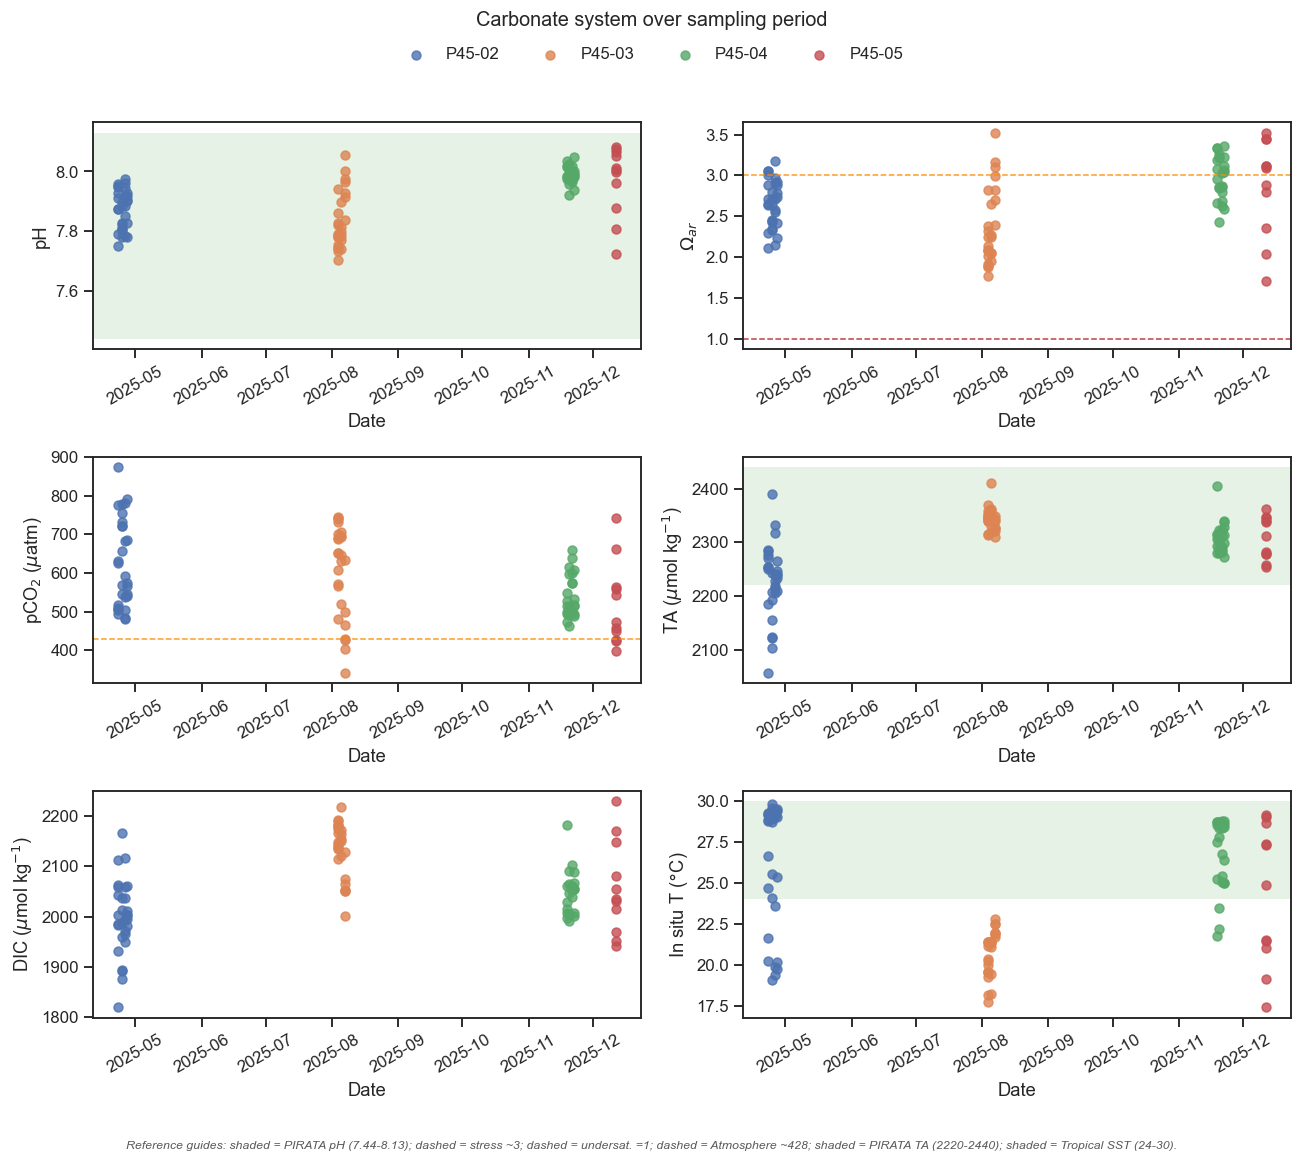


--- Time series: data summary ---
  - n = 91 sample rows.
  - Mean Omega_ar lowest at P45-03 (2.37) and highest at P45-04 (2.99).
  - Mean pCO2 highest at P45-02 (623 uatm).
  - 71% of samples below the stress guide (Omega_ar about 3); 0% below undersaturation (Omega_ar=1).
  - 93% of samples exceed atmospheric pCO2 (~428 uatm), i.e. a CO2 source to the atmosphere.


In [5]:
def fig_timeseries(df, col):
    if "date" not in col:
        print("no date column; skip"); return
    vars_ = [v for v in ["ph","omega_ar","pco2","ta","dic","temp_insitu"] if v in col]
    grp = "cruise" if "cruise" in col else ("transect" if "transect" in col else None)
    n=len(vars_); nrow=(n+1)//2
    fig, axes = plt.subplots(nrow, 2, figsize=(12, 3.2*nrow), squeeze=False)
    for i, v in enumerate(vars_):
        ax = axes[i//2][i%2]
        if grp:
            for g, gd in df.groupby(col[grp]):
                ax.scatter(gd[col["date"]], gd[col[v]], label=str(g), s=34, alpha=0.8)
        else:
            ax.scatter(df[col["date"]], df[col[v]], s=34, alpha=0.8)
        add_refs(ax, v, "y")
        ax.set_ylabel(label_of(v)); ax.set_xlabel("Date"); ax.tick_params(axis="x", rotation=30)
    for j in range(n, nrow*2): axes[j//2][j%2].axis("off")
    if grp:
        h,l = axes[0][0].get_legend_handles_labels()
        fig.legend(h,l, loc="upper center", ncol=min(6,len(l)), bbox_to_anchor=(0.5,1.03))
    fig.suptitle("Carbonate system over sampling period", y=1.05, fontsize=13)
    add_ref_caption(fig, vars_)
    fig.tight_layout(); _save(fig, "timeseries_by_cruise"); plt.show()
    show_deductions("Time series", deduce(df, col, group_canon="cruise"))

fig_timeseries(df, col)

## 5. Seasonal depth profiles

Recycled from `make_season_grid_pub`. Rows are variables, columns are seasons;
each line is a station, colored consistently. Reference guides are drawn on the
x-axis. Depth increases downward.

saved oa_figures\season_depth_profiles.png


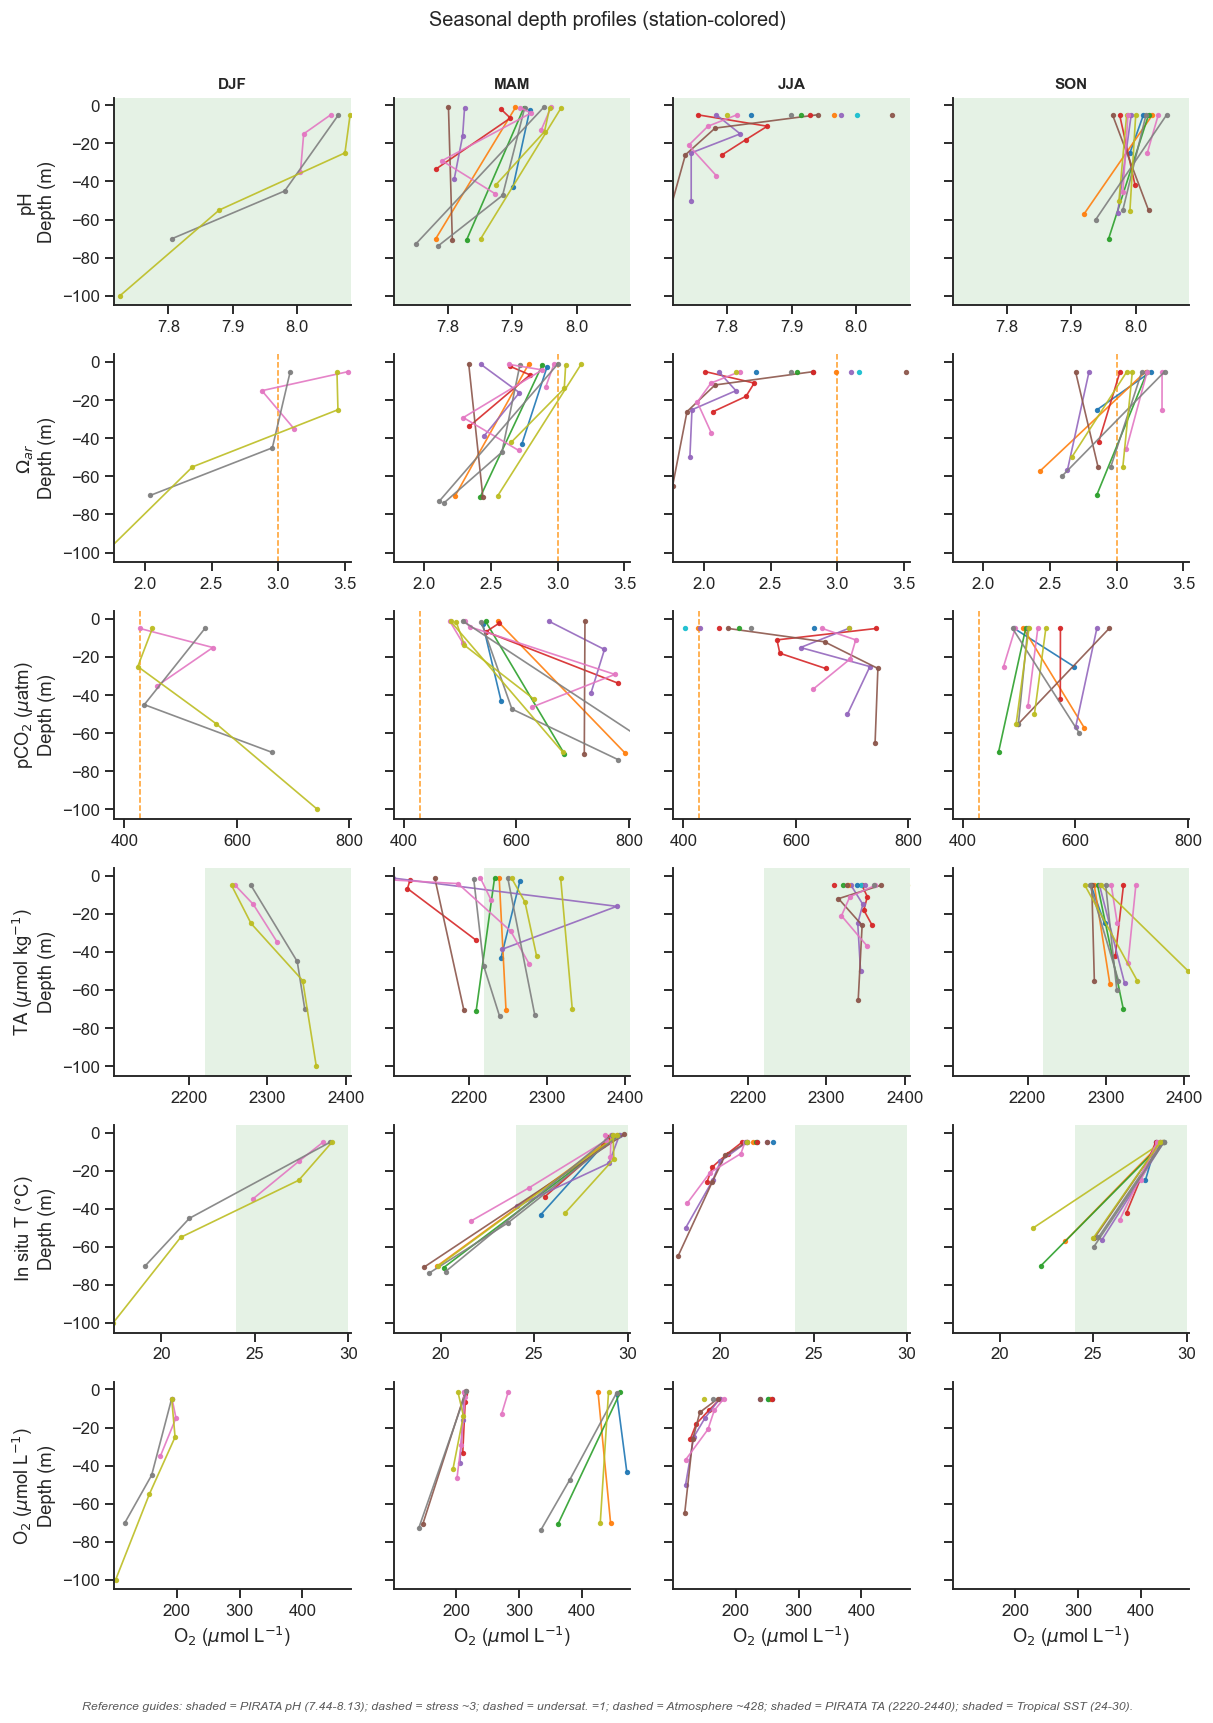

In [6]:
def fig_season_profiles(df, col):
    if "depth" not in col or "season" not in df.columns:
        print("need depth + season; skip"); return
    vars_ = [v for v in ["ph","omega_ar","pco2","ta","temp_insitu","oxygen"] if v in col]
    order = ("DJF","MAM","JJA","SON")
    seasons = sorted(df["season"].dropna().unique(),
                     key=lambda s: order.index(s) if s in order else 99)
    if not vars_ or not seasons:
        print("nothing to plot; skip"); return
    stations = np.sort(df[col["station"]].dropna().unique()) if "station" in col else []
    pal = sns.color_palette("tab10", max(3, len(stations)))
    stc = {s: pal[i%len(pal)] for i,s in enumerate(stations)}
    nrow, ncol = len(vars_), len(seasons)
    fig, axes = plt.subplots(nrow, ncol, figsize=(2.8*ncol, 2.5*nrow), sharey=True, squeeze=False)
    for r, v in enumerate(vars_):
        xlim = robust_limits(df[col[v]])
        for c, seas in enumerate(seasons):
            ax = axes[r][c]; sub = df[df["season"]==seas]
            if sub.empty: ax.set_axis_off(); continue
            if "station" in col:
                g = sub.groupby([col["station"], col["depth"]])[col[v]].mean().reset_index()
                for st, gg in g.groupby(col["station"]):
                    gg = gg.sort_values(col["depth"])
                    ax.plot(gg[col[v]], -gg[col["depth"]], lw=1.1, marker="o", ms=2.5,
                            color=stc.get(st,"0.3"), alpha=0.9)
            else:
                g = sub.groupby(col["depth"])[col[v]].mean().reset_index().sort_values(col["depth"])
                ax.plot(g[col[v]], -g[col["depth"]], lw=1.1, marker="o", ms=2.5, color="0.2")
            add_refs(ax, v, "x")
            if xlim: ax.set_xlim(*xlim)
            if r == nrow-1: ax.set_xlabel(label_of(v))
            ax.set_ylabel(f"{label_of(v)}\nDepth (m)" if c==0 else "")
            if r == 0: ax.set_title(seas, fontsize=10)
            sns.despine(ax=ax)
    fig.suptitle("Seasonal depth profiles (station-colored)", y=1.005, fontsize=13)
    add_ref_caption(fig, vars_)
    fig.tight_layout(); _save(fig, "season_depth_profiles"); plt.show()

fig_season_profiles(df, col)

## 6. Distributions by transect (with GoG guides)

Recycled from `make_by_location_boxplots`. Boxplots of key variables per transect,
with jittered points and the Gulf of Guinea reference bands/lines overlaid.

saved oa_figures\by_transect_boxplots.png


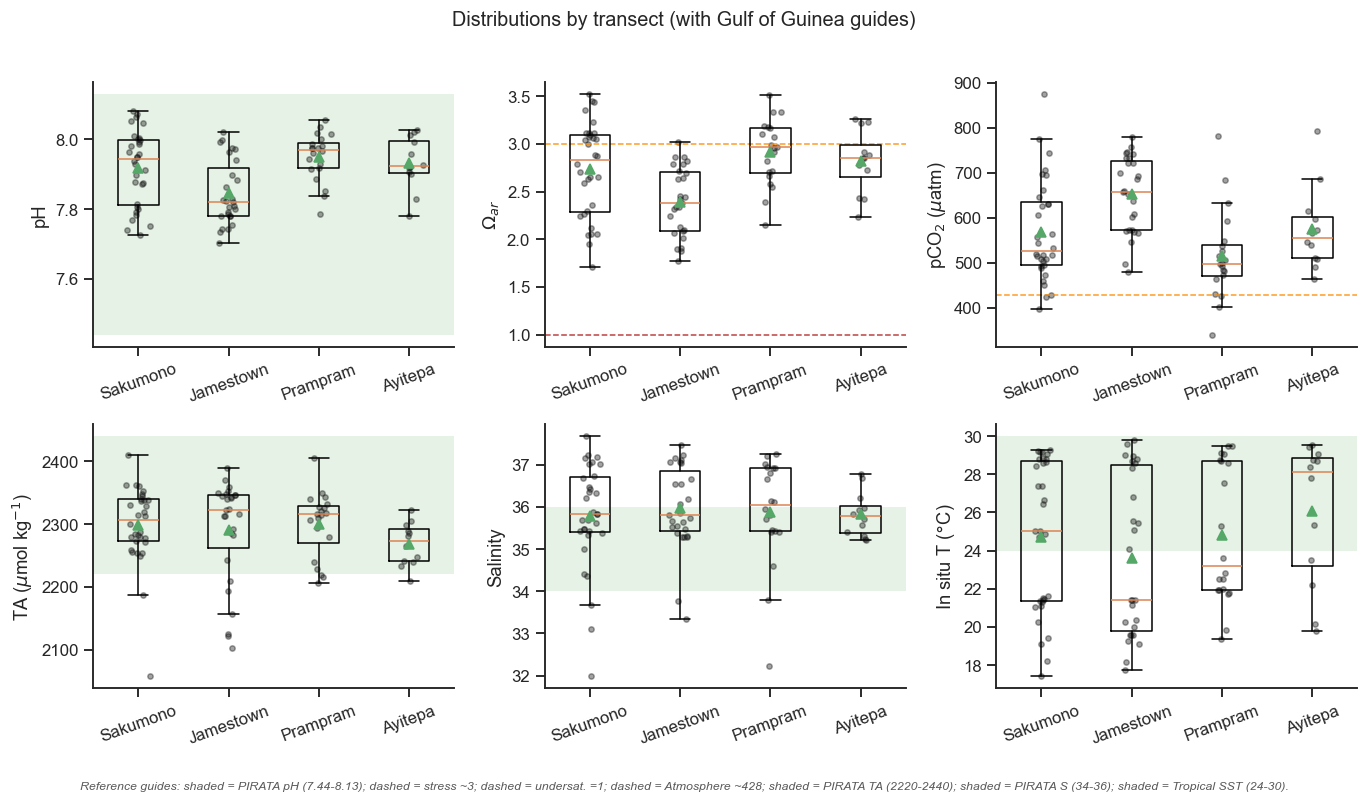


--- By transect: data summary ---
  - n = 91 sample rows.
  - Mean Omega_ar lowest at Jamestown (2.39) and highest at Prampram (2.92).
  - Mean pCO2 highest at Jamestown (652 uatm).
  - 71% of samples below the stress guide (Omega_ar about 3); 0% below undersaturation (Omega_ar=1).
  - 93% of samples exceed atmospheric pCO2 (~428 uatm), i.e. a CO2 source to the atmosphere.

--- West->east gradient (data): data summary ---
  - West->east order checked as: Jamestown -> Sakumono -> Prampram -> Ayitepa.
  - temp rises west->east (23.62 -> 26.05).
  - pH rises west->east (7.85 -> 7.93).
  - Omega_ar rises west->east (2.39 -> 2.82).
  - pCO2 falls west->east (651.67 -> 574.02).
  - salinity falls west->east (35.97 -> 35.82).
  - TA falls west->east (2289.85 -> 2268.06).

=== By transect: narrative (generated from the data; citations for the patterns shown) ===
  Spatial structure is a coherent west-to-east gradient. Jamestown (west) carries the
  strongest upwelling signature - cooler, lowe

In [7]:
def fig_transect_boxes(df, col):
    if "transect" not in col:
        print("no transect column; skip"); return
    vars_ = [v for v in ["ph","omega_ar","pco2","ta","sal","temp_insitu"] if v in col]
    cats = list(df[col["transect"]].dropna().unique())
    n=len(vars_); ncol=3; nrow=(n+ncol-1)//ncol
    fig, axes = plt.subplots(nrow, ncol, figsize=(4.2*ncol, 3.4*nrow), squeeze=False)
    for i, v in enumerate(vars_):
        ax = axes[i//ncol][i%ncol]
        data = [df.loc[df[col["transect"]]==c, col[v]].dropna().values for c in cats]
        labels = [str(c) for c in cats]
        try:
            ax.boxplot(data, tick_labels=labels, showfliers=False, showmeans=True)
        except TypeError:
            ax.boxplot(data, labels=labels, showfliers=False, showmeans=True)
        for xi, arr in enumerate(data, 1):
            ax.scatter(np.random.normal(xi, 0.05, len(arr)), arr, s=12, alpha=0.4, color="k")
        add_refs(ax, v, "y")
        ax.set_ylabel(label_of(v)); ax.tick_params(axis="x", rotation=20); sns.despine(ax=ax)
    for j in range(n, nrow*ncol): axes[j//ncol][j%ncol].axis("off")
    fig.suptitle("Distributions by transect (with Gulf of Guinea guides)", y=1.01, fontsize=13)
    add_ref_caption(fig, vars_)
    fig.tight_layout(); _save(fig, "by_transect_boxplots"); plt.show()
    show_deductions("By transect", deduce(df, col, group_canon="transect"))

    # Data-backed check of the stated west->east spatial ordering.
    WEST_TO_EAST = ["Jamestown", "Sakumono", "Prampram", "Ayitepa"]
    grad = transect_gradient_check(df, col, WEST_TO_EAST)
    if grad:
        show_deductions("West->east gradient (data)", grad)

    # Auto-detect uneven coverage to decide whether to emit the caveat.
    coverage = None
    if "transect" in col and "date" in col:
        cov = df.groupby(col["transect"])[col["date"]].apply(
            lambda s: sorted(pd.to_datetime(s, errors="coerce").dt.to_period("M").dropna().astype(str).unique()))
        spans = {t: v for t, v in cov.items()}
        n_months = {t: len(v) for t, v in spans.items()}
        if len(set(n_months.values())) > 1:  # uneven month coverage across transects
            sparse = sorted(n_months, key=n_months.get)[:2]
            coverage = ("sampling coverage is uneven across transects and months "
                        + "; ".join(f"{t}: {', '.join(spans[t])}" for t in sparse)
                        + ". In any time-step analysis hold transect constant and avoid pooling, "
                          "or a 'seasonal' signal risks being a spatial-sampling artifact.")

    # Data-driven narrative (story built from the computed pattern, with citations).
    story = narrate_transect(df, col, WEST_TO_EAST, coverage_note=coverage)
    if story:
        show_interpretation("By transect", story)

fig_transect_boxes(df, col)

## 7. Relationships (cross-plots)

Ω_ar vs pH, TA vs salinity (mixing), pCO₂ vs temperature, and Ω_ar vs depth.
Colored by cruise; saturation reference on Ω_ar axes.

saved oa_figures\crossplots.png


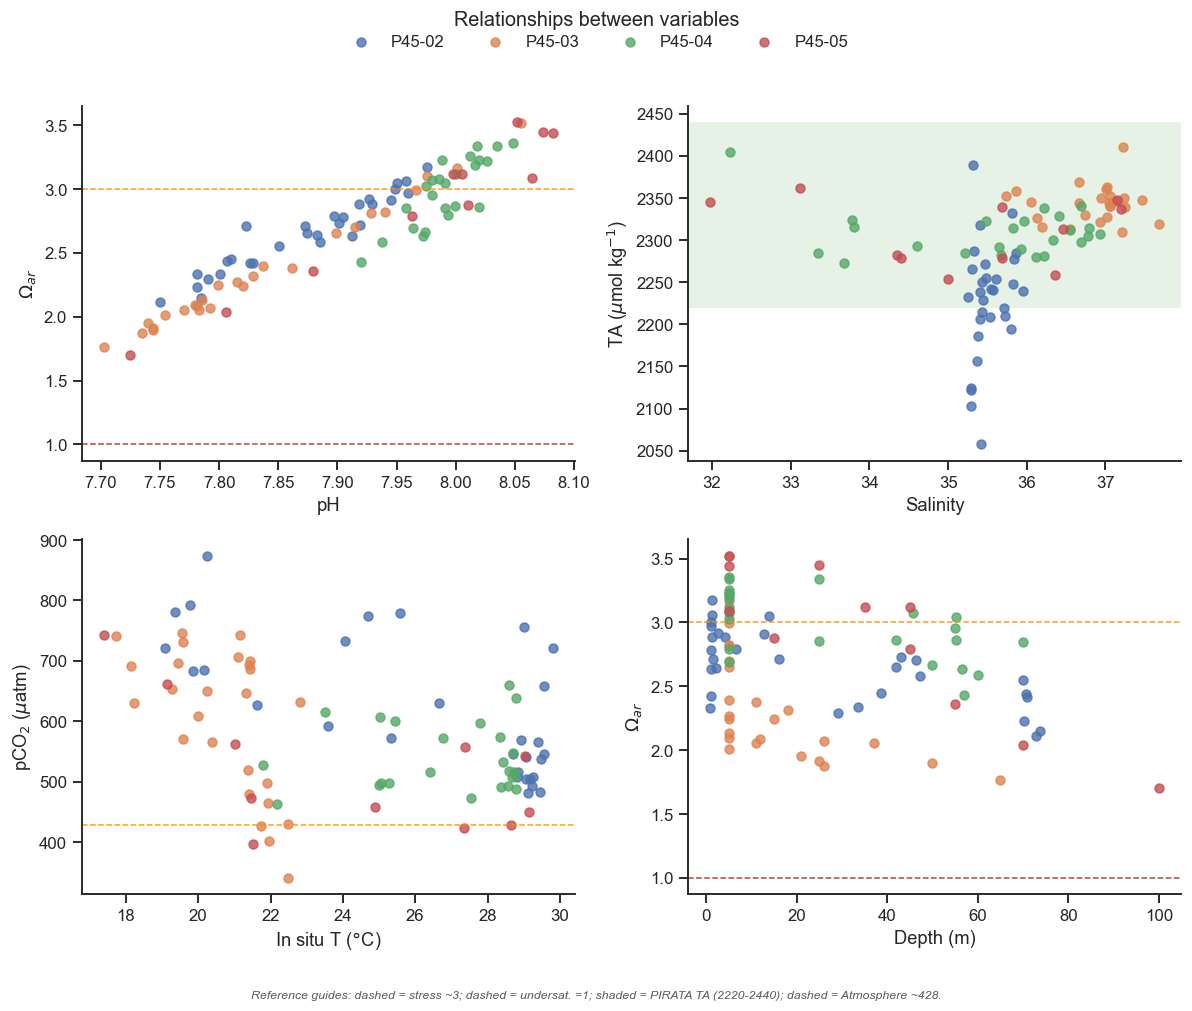

In [8]:
def fig_crossplots(df, col):
    pairs = [("ph","omega_ar"),("sal","ta"),("temp_insitu","pco2"),("depth","omega_ar")]
    pairs = [(x,y) for x,y in pairs if x in col and y in col]
    grp = "cruise" if "cruise" in col else None
    n=len(pairs); nrow=(n+1)//2
    fig, axes = plt.subplots(nrow, 2, figsize=(11, 4.2*nrow), squeeze=False)
    for i,(xv,yv) in enumerate(pairs):
        ax = axes[i//2][i%2]
        if grp:
            for g, gd in df.groupby(col[grp]):
                ax.scatter(gd[col[xv]], gd[col[yv]], label=str(g), s=34, alpha=0.8)
        else:
            ax.scatter(df[col[xv]], df[col[yv]], s=34, alpha=0.8)
        add_refs(ax, yv, "y")
        ax.set_xlabel(label_of(xv)); ax.set_ylabel(label_of(yv)); sns.despine(ax=ax)
    for j in range(n, nrow*2): axes[j//2][j%2].axis("off")
    if grp:
        h,l = axes[0][0].get_legend_handles_labels()
        fig.legend(h,l, loc="upper center", ncol=min(6,len(l)), bbox_to_anchor=(0.5,1.03))
    fig.suptitle("Relationships between variables", y=1.04, fontsize=13)
    add_ref_caption(fig, [yv for _, yv in pairs])
    fig.tight_layout(); _save(fig, "crossplots"); plt.show()

fig_crossplots(df, col)

## 8. Station map (cartopy coastline, with graceful fallback)

Adapted from the old `make_profiles.py`. If **cartopy** is installed it draws a
proper coastline/land map using cartopy's built-in features (no local ETOPO
bathymetry file required); otherwise it falls back to a plain lon/lat scatter with
correct aspect. Points are colored by Ω_ar (or pH). For a full bathymetric
backdrop later, drop an ETOPO subset in and extend this cell.

saved oa_figures\station_map.png


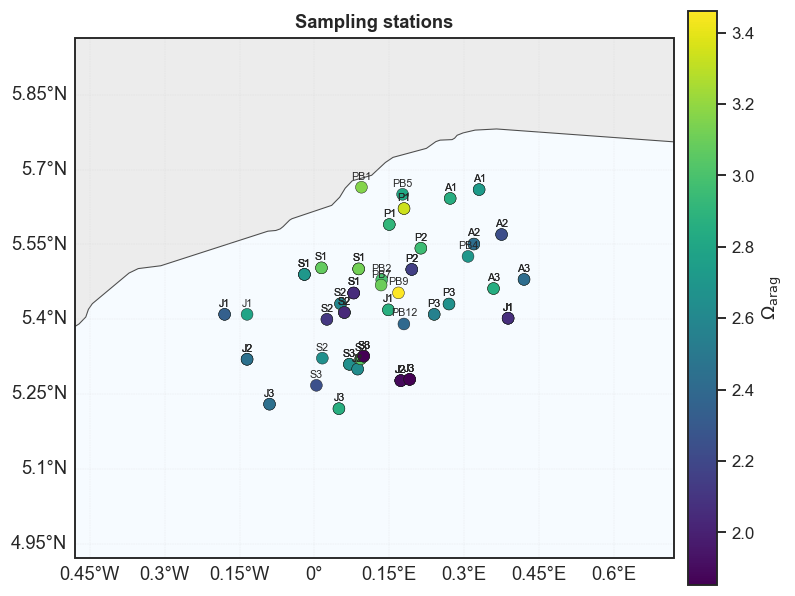

In [9]:
def fig_map(df, col):
    if "lat" not in col or "lon" not in col:
        print("no lat/lon; skip"); return
    cvar = "omega_ar" if "omega_ar" in col else ("ph" if "ph" in col else None)
    d = df.dropna(subset=[col["lat"], col["lon"]]).copy()
    if d.empty:
        print("no coordinates; skip"); return

    # color scaling
    vmin = vmax = None
    if cvar:
        vals = d[col[cvar]].to_numpy()
        if np.isfinite(vals).any():
            vmin, vmax = np.nanpercentile(vals, [2, 98])

    # --- try cartopy (built-in coastlines, no ETOPO needed) ---
    try:
        import cartopy.crs as ccrs
        import cartopy.feature as cfeature
        proj = ccrs.PlateCarree()
        pad = 0.3
        lon0, lon1 = d[col["lon"]].min()-pad, d[col["lon"]].max()+pad
        lat0, lat1 = d[col["lat"]].min()-pad, d[col["lat"]].max()+pad
        fig = plt.figure(figsize=(7.5, 6.5))
        ax = plt.axes(projection=proj)
        ax.set_extent([lon0, lon1, lat0, lat1], crs=proj)
        ax.add_feature(cfeature.LAND, facecolor="#ececec", zorder=1)
        ax.add_feature(cfeature.OCEAN, facecolor="#f6fbff", zorder=0)
        ax.coastlines(resolution="10m", linewidth=0.7, color="0.3", zorder=2)
        ax.add_feature(cfeature.BORDERS, linewidth=0.4, edgecolor="0.5", zorder=2)
        if cvar:
            s = ax.scatter(d[col["lon"]], d[col["lat"]], c=d[col[cvar]], cmap="viridis",
                           vmin=vmin, vmax=vmax, s=60, edgecolor="k", linewidth=0.3,
                           transform=proj, zorder=3)
            cb = fig.colorbar(s, ax=ax, shrink=0.85, pad=0.02)
            cb.set_label(chem("Omega_ar") if cvar == "omega_ar" else "pH")
        else:
            ax.scatter(d[col["lon"]], d[col["lat"]], s=50, transform=proj, zorder=3)
        if "station" in col:
            for x, y, lab in zip(d[col["lon"]], d[col["lat"]], d[col["station"]]):
                ax.annotate(str(lab), (x, y), xytext=(0, 5), textcoords="offset points",
                            ha="center", fontsize=7, transform=proj)
        gl = ax.gridlines(draw_labels=True, linestyle="--", linewidth=0.3, alpha=0.4)
        gl.top_labels = gl.right_labels = False
        ax.set_title("Sampling stations")
        fig.tight_layout(); _save(fig, "station_map"); plt.show()
        return
    except Exception as e:
        print(f"cartopy unavailable ({type(e).__name__}); plain scatter fallback")

    # --- fallback: plain lon/lat scatter with geographic aspect ---
    fig, ax = plt.subplots(figsize=(7, 6))
    if cvar:
        s = ax.scatter(d[col["lon"]], d[col["lat"]], c=d[col[cvar]], cmap="viridis",
                       vmin=vmin, vmax=vmax, s=55, edgecolor="k", linewidth=0.3)
        fig.colorbar(s, ax=ax, label=(chem("Omega_ar") if cvar == "omega_ar" else "pH"))
    else:
        ax.scatter(d[col["lon"]], d[col["lat"]], s=45)
    if "station" in col:
        for x, y, lab in zip(d[col["lon"]], d[col["lat"]], d[col["station"]]):
            ax.annotate(str(lab), (x, y), xytext=(0, 5), textcoords="offset points",
                        ha="center", fontsize=7)
    midlat = float(d[col["lat"]].mean())
    ax.set_aspect(1.0 / np.cos(np.deg2rad(midlat)))   # geographic aspect
    ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
    ax.set_title("Sampling stations"); sns.despine(ax=ax)
    fig.tight_layout(); _save(fig, "station_map"); plt.show()

fig_map(df, col)

---
### Notes & next steps

- To run on the pipeline output instead, set `INPUT` to your `analysis_ready.csv` —
  the column resolver handles the different names automatically.
- Turn reference guides off with `REFS = False` in the config cell.
- Styling: if `src/viz/style.py` is importable, the notebook uses your
  `set_pub_defaults()` and `chem()`; otherwise it falls back to seaborn defaults.
- The station map uses cartopy coastlines when available and falls back to a plain
  geographic scatter otherwise — no ETOPO file required. For a bathymetric backdrop,
  extend the map cell with an ETOPO subset later.
- Recycled from the old scripts: seasonal-profile grid and transect boxplots
  (`make_figures.py`), the cartopy map approach (`make_profiles.py`), and the
  `chem()` label helper / `set_pub_defaults()` (`src/viz/style.py`). The flux
  ribbon and heatbox sections were left out (need flux/CTD data not in the prelim set).